## Imports
This cell imports the core libraries used by the GP maze solver described in `GP.pdf`:
- `random` for stochastic initialization, selection, crossover, and mutation.
- `copy` for safe deep-copy operations on GP trees.
- `matplotlib.pyplot` for fitness/path visualizations required in the assignment.

**Theory**
Genetic Programming (GP) searches in the space of executable program trees:
$$
T^* = \arg\min_{T \in \mathcal{T}} F(T)
$$
where `T` is a tree-structured policy and `F(T)` is its fitness on the maze task.


In [1]:
import random
import copy
import matplotlib.pyplot as plt


## Problem Setup (Maze, Start, Goal)
This cell defines the exact maze instance from the documentation (10x10 grid), where:
- `0` means walkable space.
- `1` means wall.
It also sets:
- `START_POS = (0, 0)` (top-left)
- `GOAL_POS = (9, 9)` (bottom-right)
and computes grid dimensions used by movement logic.

**Theory**
The state space is the set of valid walkable coordinates:
$$
\mathcal{S} = \{(r,c) \mid 0 \le r < H,\ 0 \le c < W,\ \text{MAZE}[r][c] = 0\}
$$
The objective is to evolve a policy that maps tree execution to actions leading from start to goal.


In [2]:
# =========================================================
# ------------------- PROBLEM SETUP -----------------------
# =========================================================

# 0 = free, 1 = wall
MAZE = [
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 1, 1, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 0, 0, 0],
]

GRID_H = len(MAZE)
GRID_W = len(MAZE[0])

START_POS = (0, 0)  # (row, col)
GOAL_POS = (9, 9)  # (row, col)


## GP Configuration and Weights
This cell sets GP hyperparameters and primitive symbols, aligned with the assignment requirements:
- population size, max generations, depth limits, step budget
- crossover and mutation rates
- fitness weights used in `F = s + 2d + 10w + 5l` when unsolved
- terminal actions (`UP`, `DOWN`, `LEFT`, `RIGHT`) and function primitive (`PROGN2`)

**Theory**
These values define the bias/variance trade-off of search:
- larger `POP_SIZE` and `MAX_GENERATIONS` improve exploration but increase cost
- depth limits control code bloat in GP trees
- rates `p_c` and `p_m` balance recombination and random structural innovation


In [3]:
# =========================================================
# ------------------- GP CONFIG (like notebook) -----------
# =========================================================

POP_SIZE = 200
MAX_GENERATIONS = 2000  # notebook uses large gen count
MAX_STEPS = 60  # evaluation step budget
MAX_TREE_DEPTH_INIT = 4  # init depth
MAX_TREE_DEPTH = 8  # absolute max depth

CROSSOVER_RATE = 0.9
MUTATION_RATE = 0.2

# Fitness weights (same formula)
WEIGHT_STEP = 1
WEIGHT_DISTANCE = 2
WEIGHT_WALL_HIT = 10
WEIGHT_LOOP = 5

# Primitives (like notebook)
TERMINALS = ["UP", "DOWN", "LEFT", "RIGHT"]
FUNCTIONS = ["PROGN2"]  # executes child1 then child2


## Tree Helper Section Header
This section introduces utilities for tree-structured individuals, the representation required by the GP formulation.


In [4]:
# =========================================================
# ------------------- TREE HELPERS ------------------------
# =========================================================


## `get_depth(tree)`
Computes the depth of a GP tree so depth constraints can be enforced during variation.

**Parameters**
- `tree`: `str | list`  
  A GP individual node. Terminals are strings; internal nodes are lists like `['PROGN2', child1, child2]`.

**Returns**
- `int`  
  Tree depth (terminal depth is `0`).

**Formula**
$$
\text{depth}(x) =
\begin{cases}
0 & \text{if } x \text{ is terminal} \\
1 + \max_{c \in \text{children}(x)} \text{depth}(c) & \text{otherwise}
\end{cases}
$$


In [5]:
def get_depth(tree):
    """Depth of nested-list GP tree. Terminal depth = 0."""
    if isinstance(tree, str):
        return 0
    return 1 + max(get_depth(child) for child in tree[1:])


## `count_nodes(tree)`
Counts the total number of nodes in a GP tree (terminals + internal nodes).

**Parameters**
- `tree`: `str | list`  
  GP tree node or subtree.

**Returns**
- `int`  
  Total node count in the subtree rooted at `tree`.


In [6]:
def count_nodes(tree):
    """Counts total nodes in a nested-list GP tree."""
    if isinstance(tree, str):
        return 1
    return 1 + sum(count_nodes(child) for child in tree[1:])


## `create_tree(depth, method='grow')`
Generates random GP trees using `grow` or `full`, matching the initialization strategy in the documentation.

**Parameters**
- `depth`: `int`  
  Remaining construction depth.
- `method`: `str`  
  `'grow'` allows early terminal stopping; `'full'` forces function nodes until depth reaches zero.

**Returns**
- `str | list`  
  A randomly generated GP tree (terminal action or nested `PROGN2` list).

**Theory**
`full` creates uniformly deep trees, while `grow` creates variable-depth trees.
Using both reduces initialization bias and improves structural diversity in early generations.


In [7]:
def create_tree(depth, method="grow"):
    """
    Generates a random GP tree (nested lists + strings).
    - method='grow': may stop early with terminals
    - method='full': forces functions until depth hits 0
    """
    if depth == 0:
        return random.choice(TERMINALS)

    if method == "grow":
        if random.random() < 0.5:
            return random.choice(TERMINALS)
        else:
            return [
                "PROGN2",
                create_tree(depth - 1, method),
                create_tree(depth - 1, method),
            ]
    else:  # full
        return [
            "PROGN2",
            create_tree(depth - 1, method),
            create_tree(depth - 1, method),
        ]


## `init_population(size)`
Initializes the population with ramped half-and-half (mix of `full` and `grow`) as required by the project.

**Parameters**
- `size`: `int`  
  Number of individuals to create.

**Returns**
- `list`  
  List of randomly initialized GP trees.

**Theory**
Ramped half-and-half approximates:
$$
\mathcal{P}_0 = \mathcal{P}_{\text{full}} \cup \mathcal{P}_{\text{grow}}, \quad
|\mathcal{P}_{\text{full}}| \approx |\mathcal{P}_{\text{grow}}| \approx \frac{N}{2}
$$
which improves initial coverage of tree shapes and depths.


In [8]:
def init_population(size):
    """Ramped Half-and-Half initialization (like notebook)."""
    pop = []
    for i in range(size):
        depth = random.randint(2, MAX_TREE_DEPTH_INIT)
        method = "full" if i % 2 == 0 else "grow"
        pop.append(create_tree(depth, method))
    return pop


## Environment/Execution Section Header
This section defines environment checks and tree execution semantics for moving inside the maze.


In [9]:
# =========================================================
# ------------------- ENV / EXECUTION ---------------------
# =========================================================


## `is_wall(r, c)`
Checks whether a target cell is blocked; out-of-bounds is treated as wall.

**Parameters**
- `r`: `int`  
  Row index.
- `c`: `int`  
  Column index.

**Returns**
- `bool`  
  `True` if the coordinate is invalid or blocked, else `False`.


In [10]:
def is_wall(r, c):
    """Out of bounds treated as wall."""
    if r < 0 or r >= GRID_H or c < 0 or c >= GRID_W:
        return True
    return MAZE[r][c] == 1


## `manhattan(p, q)`
Computes Manhattan distance used by the fitness term `d`.

**Parameters**
- `p`: `tuple[int, int]`  
  First grid position.
- `q`: `tuple[int, int]`  
  Second grid position.

**Returns**
- `int`  
  `|p_row - q_row| + |p_col - q_col|`.

**Formula**
$$
d_{\text{Manhattan}}(p,q) = |p_r - q_r| + |p_c - q_c|
$$


In [11]:
def manhattan(p, q):
    return abs(p[0] - q[0]) + abs(p[1] - q[1])


## `execute_tree(tree, path, wall_hits)`
Executes a GP tree recursively to generate movement behavior in the maze.
It enforces stopping conditions from the assignment setup (max steps / reaching goal).

**Parameters**
- `tree`: `str | list`  
  GP program node to execute.
- `path`: `list[tuple[int, int]]`  
  Mutable trajectory; starts at `START_POS` and grows with each action.
- `wall_hits`: `list[int]`  
  Single-item mutable counter (`wall_hits[0]`) incremented when movement hits a wall.

**Returns**
- `bool`  
  `True` if execution should stop early (goal reached or step limit), else `False`.

**Theory**
The internal primitive `PROGN2(a,b)` is sequential composition:
$$
\text{Exec}(\text{PROGN2}(a,b), s) = \text{Exec}(b, \text{Exec}(a, s))
$$
with short-circuit stopping if `MAX_STEPS` is reached or goal is achieved.


In [12]:
def execute_tree(tree, path, wall_hits):
    """
    Recursively executes a GP tree.
    - path is a list of visited positions (row, col)
    - wall_hits is a single-element list so it is mutable by recursion

    Stops early if:
    - max steps reached
    - goal reached
    """
    # stop if step budget reached
    if len(path) - 1 >= MAX_STEPS:
        return True

    # stop if goal reached
    current = path[-1]
    if current == GOAL_POS:
        return True

    # TERMINAL -> movement
    if isinstance(tree, str):
        r, c = current
        dr, dc = 0, 0

        if tree == "UP":
            dr = -1
        elif tree == "DOWN":
            dr = 1
        elif tree == "LEFT":
            dc = -1
        elif tree == "RIGHT":
            dc = 1

        nr, nc = r + dr, c + dc

        if is_wall(nr, nc):
            wall_hits[0] += 1
            # stay in place (not appending new pos) OR append same pos:
            # notebook usually keeps position unchanged; we append the same position to reflect "step happened"
            path.append((r, c))
        else:
            path.append((nr, nc))

        return False

    # FUNCTION -> PROGN2
    # execute child 1 then child 2
    stop = execute_tree(tree[1], path, wall_hits)
    if stop:
        return True
    stop = execute_tree(tree[2], path, wall_hits)
    if stop:
        return True
    return False


## Fitness Section Header
This section implements the minimization objective specified in `GP.pdf`.


In [13]:
# =========================================================
# ------------------- FITNESS -----------------------------
# =========================================================


## `calculate_fitness(individual)`
Evaluates one GP individual using the project fitness definition.
If solved perfectly (goal reached and zero wall hits), fitness is `0`.
Otherwise it applies `F = s + 2d + 10w + 5l`.

**Parameters**
- `individual`: `str | list`  
  GP tree representing an agent policy.

**Returns**
- `tuple[float, list[tuple[int, int]]]`  
  `(fitness_score, path)` where `path` is the visited trajectory.

**Formula (from GP.pdf)**
$$
F =
\begin{cases}
0 & \text{if goal reached and } w=0 \\
s + 2d + 10w + 5l & \text{otherwise}
\end{cases}
$$
where:
- $s$: number of executed steps
- $d$: Manhattan distance from final position to goal
- $w$: wall-hit count
- $l = |\text{path}| - |\text{unique(path)}|$: revisit/loop penalty


In [14]:
def calculate_fitness(individual):
    """
    Fitness (minimize):
      F = s + 2d + 10w + 5l
    where:
      s = steps (len(path)-1)
      d = Manhattan distance of final position to goal
      w = wall hits
      l = loops (len(path)-len(set(path)))

    NOTE: Like the notebook, we treat "perfect solution" as:
      reached goal AND wall_hits == 0  -> fitness 0
    """
    path = [START_POS]
    wall_hits = [0]

    execute_tree(individual, path, wall_hits)

    final_pos = path[-1]
    steps = len(path) - 1
    dist = manhattan(final_pos, GOAL_POS)
    w = wall_hits[0]
    loops = len(path) - len(set(path))

    # Notebook-like "perfect" check
    if final_pos == GOAL_POS and w == 0:
        return 0.0, path

    score = (
        (steps * WEIGHT_STEP)
        + (dist * WEIGHT_DISTANCE)
        + (w * WEIGHT_WALL_HIT)
        + (loops * WEIGHT_LOOP)
    )

    return float(score), path


## Selection Section Header
This section defines parent selection for reproduction.


In [15]:
# =========================================================
# ------------------- SELECTION (roulette) ----------------
# =========================================================


## `fitness_proportionate_selection(population, fitnesses)`
Performs roulette-wheel selection adapted for minimization (lower fitness -> higher probability).

**Parameters**
- `population`: `list`  
  Current list of GP trees.
- `fitnesses`: `list[float]`  
  Fitness score for each individual.

**Returns**
- `str | list`  
  A deep-copied selected parent individual.

**Formula**
For minimization, weights are inverted:
$$
w_i = (f_{\max} - f_i) + \varepsilon
$$
then selection probability is:
$$
P(i) = \frac{w_i}{\sum_j w_j}
$$
So smaller fitness gives larger selection probability.


In [16]:
def fitness_proportionate_selection(population, fitnesses):
    """
    Roulette selection adapted for minimization:
    lower fitness => higher selection probability.
    """
    max_f = max(fitnesses)
    weights = [(max_f - f) + 1e-6 for f in fitnesses]  # invert
    total = sum(weights)

    if total <= 0:
        idx = random.randrange(len(population))
    else:
        idx = random.choices(range(len(population)), weights=weights, k=1)[0]

    return copy.deepcopy(population[idx])


## Subtree Operations Section Header
This section implements GP structural variation on trees (subtree sampling/replacement).


In [17]:
# =========================================================
# ------------------- SUBTREE OPS -------------------------
# =========================================================


## `get_random_subtree(tree)` (+ internal `collect(n)`)
Collects all nodes in a tree and returns one random subtree used by crossover.

**Parameters (`get_random_subtree`)**
- `tree`: `str | list`  
  Input GP individual.

**Returns (`get_random_subtree`)**
- `str | list`  
  One randomly chosen node/subtree reference.

**Parameters (`collect`)**
- `n`: `str | list`  
  Current node during depth-first traversal.

**Returns (`collect`)**
- `None`  
  Appends nodes into outer `nodes` list by side effect.


In [18]:
def get_random_subtree(tree):
    """Collect all node references and return one random subtree."""
    nodes = []

    def collect(n):
        nodes.append(n)
        if not isinstance(n, str):
            for ch in n[1:]:
                collect(ch)

    collect(tree)
    return random.choice(nodes)


## `replace_random_subtree(tree, new_subtree)`
Randomly replaces part of a GP tree with another subtree (used by crossover/mutation).

**Parameters**
- `tree`: `str | list`  
  Original individual.
- `new_subtree`: `str | list`  
  Replacement branch.

**Returns**
- `str | list`  
  Modified tree after stochastic replacement decisions.


In [19]:
def replace_random_subtree(tree, new_subtree):
    """
    Replace a random node in 'tree' with 'new_subtree'.
    This is stochastic (like notebook): sometimes replaces terminals, sometimes internal nodes.
    """
    if isinstance(tree, str):
        # 50% chance replace terminal
        return new_subtree if random.random() < 0.5 else tree

    # small chance replace current internal node
    if random.random() < 0.1:
        return new_subtree

    op = tree[0]
    children = [replace_random_subtree(ch, new_subtree) for ch in tree[1:]]
    return [op] + children


## `crossover(parent1, parent2)`
Applies subtree crossover by inserting a random subtree from `parent2` into `parent1`.
Depth constraint is enforced (`MAX_TREE_DEPTH`).

**Parameters**
- `parent1`: `str | list`  
  Base parent to be modified.
- `parent2`: `str | list`  
  Donor parent for subtree extraction.

**Returns**
- `str | list`  
  Child tree if crossover is accepted and valid; otherwise original `parent1`.

**Theory/Formula**
With probability $p_c$:
$$
\text{child} = \text{ReplaceSubtree}(p_1, \text{RandomSubtree}(p_2))
$$
accepted only if:
$$
\text{depth(child)} \le \text{MAX\_TREE\_DEPTH}
$$


In [20]:
def crossover(parent1, parent2):
    """Subtree crossover: replace a random subtree in parent1 with random subtree from parent2."""
    if random.random() > CROSSOVER_RATE:
        return parent1

    subtree = get_random_subtree(parent2)
    child = replace_random_subtree(copy.deepcopy(parent1), copy.deepcopy(subtree))

    # enforce max depth
    if get_depth(child) > MAX_TREE_DEPTH:
        return parent1
    return child


## `mutate(individual)`
Applies subtree mutation by replacing a random subtree with a small random branch.
Depth constraint is enforced (`MAX_TREE_DEPTH`).

**Parameters**
- `individual`: `str | list`  
  Parent individual to mutate.

**Returns**
- `str | list`  
  Mutated child if mutation occurs and is valid; otherwise original individual.

**Theory/Formula**
With probability $p_m$:
$$
\text{child} = \text{ReplaceSubtree}(x, \text{RandomBranch})
$$
then keep `child` only if it respects max-depth constraints.


In [21]:
def mutate(individual):
    """Subtree mutation: replace a random subtree with a small random branch."""
    if random.random() > MUTATION_RATE:
        return individual

    mutation_branch = create_tree(2, "grow")
    child = replace_random_subtree(copy.deepcopy(individual), mutation_branch)

    if get_depth(child) > MAX_TREE_DEPTH:
        return individual
    return child


## Visualization Section Header
This section provides visualization of individuals/paths for qualitative inspection, as requested in deliverables.


In [22]:
# =========================================================
# ------------------- VISUALIZATION -----
# =========================================================


## `visualize_generation(population, fitnesses, paths, gen, num_individuals=12, cols=4)`
Displays a sampled grid of individuals in one generation with maze, trajectory, and key markers.

**Parameters**
- `population`: `list`  
  Individuals in current generation.
- `fitnesses`: `list[float]`  
  Fitness for each individual.
- `paths`: `list[list[tuple[int, int]]]`  
  Trajectory per individual.
- `gen`: `int`  
  Generation index for title/labeling.
- `num_individuals`: `int`  
  Number of sampled individuals to display.
- `cols`: `int`  
  Number of subplot columns.

**Returns**
- `None`  
  Creates and shows a matplotlib figure.


In [23]:
def visualize_generation(population, fitnesses, paths, gen, num_individuals=12, cols=4):
    """
    Show a grid of sample individuals for a generation,
    maze + path + start/goal/final.
    """
    # pick random sample of individuals (diversity like notebook)
    n = min(num_individuals, len(population))
    idxs = random.sample(range(len(population)), n)

    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1:
        axes = axes.reshape(1, -1)
    fig.suptitle(
        f"Generation {gen} - Sample Individuals", fontsize=16, fontweight="bold"
    )

    for k in range(rows * cols):
        r = k // cols
        c = k % cols
        ax = axes[r][c]

        if k >= n:
            ax.axis("off")
            continue

        i = idxs[k]
        fit = fitnesses[i]
        path = paths[i]

        ax.imshow(MAZE, interpolation="nearest", cmap="gray_r")
        ax.set_xticks(range(GRID_W))
        ax.set_yticks(range(GRID_H))
        ax.grid(True, alpha=0.25)

        # path
        ys = [p[1] for p in path]  # col
        xs = [p[0] for p in path]  # row
        ax.plot(ys, xs, linewidth=2)  # default blue

        # start (green), goal (red), final (orange)
        ax.scatter([START_POS[1]], [START_POS[0]], s=70, color="green")
        ax.scatter([GOAL_POS[1]], [GOAL_POS[0]], s=70, color="red")
        ax.scatter([path[-1][1]], [path[-1][0]], s=50, color="orange")

        ax.set_title(f"Individual {k+1}\nFitness: {fit:.1f}", fontsize=10)
        ax.set_xlim(-0.5, GRID_W - 0.5)
        ax.set_ylim(GRID_H - 0.5, -0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


## Evolution Section Header
This section defines the main GP optimization loop and stopping criteria from the assignment.


In [24]:
# =========================================================
# ------------------- EVOLUTION (steady-state) ------------
# =========================================================


## `evolve(seed=7, visualize_gen0=True)`
Runs steady-state GP evolution: initialize, evaluate, select parents, generate offspring, and replace worst when improved.
Terminates on perfect solution (`fitness == 0`) or generation limit.

**Parameters**
- `seed`: `int`  
  Random seed for reproducibility.
- `visualize_gen0`: `bool`  
  If `True`, displays a sample of the initial population.

**Returns**
- `tuple`  
  `(best_individual, best_fitness, best_path, avg_history, best_history)`.

**Theory**
Per generation (steady-state):
1. Select two parents by roulette minimization.
2. Produce two offspring via crossover+mutation.
3. Replace current worst individuals only if offspring are better.

Replacement criterion:
$$
\text{if } f_{\text{child}} < f_{\text{worst}} \Rightarrow \text{replace}
$$
Termination:
$$
f_{\text{best}} = 0 \quad \text{or} \quad g = \text{MAX\_GENERATIONS}
$$


In [25]:
def evolve(seed=7, visualize_gen0=True):
    random.seed(seed)

    population = init_population(POP_SIZE)

    best_hist = []
    avg_hist = []

    # Evaluate initial population
    fitnesses = []
    paths = []
    for ind in population:
        f, p = calculate_fitness(ind)
        fitnesses.append(f)
        paths.append(p)

    if visualize_gen0:
        print("Visualizing first generation sample...")
        visualize_generation(
            population, fitnesses, paths, gen=0, num_individuals=12, cols=4
        )

    for gen in range(1, MAX_GENERATIONS + 1):
        # stats
        best_f = min(fitnesses)
        avg_f = sum(fitnesses) / len(fitnesses)
        best_idx = fitnesses.index(best_f)

        best_hist.append(best_f)
        avg_hist.append(avg_f)

        if gen % 50 == 0 or best_f == 0.0:
            print(
                f"Gen {gen:04d} | avg={avg_f:8.2f} | best={best_f:8.2f} | depth={get_depth(population[best_idx]):2d}"
            )

        # stop if solved
        if best_f == 0.0:
            print("Perfect solution found (goal reached with zero wall hits).")
            break

        # --- steady-state: create 2 offspring ---
        # parent selection
        p1 = fitness_proportionate_selection(population, fitnesses)
        p2 = fitness_proportionate_selection(population, fitnesses)

        # crossover + mutation
        child1 = mutate(crossover(p1, p2))
        child2 = mutate(crossover(p2, p1))

        # evaluate children
        c1_fit, c1_path = calculate_fitness(child1)
        c2_fit, c2_path = calculate_fitness(child2)

        # replace worst if better (like notebook style)
        for child, cfit, cpath in [
            (child1, c1_fit, c1_path),
            (child2, c2_fit, c2_path),
        ]:
            worst_idx = fitnesses.index(max(fitnesses))
            if cfit < fitnesses[worst_idx]:
                population[worst_idx] = child
                fitnesses[worst_idx] = cfit
                paths[worst_idx] = cpath

    # final best
    best_f = min(fitnesses)
    best_idx = fitnesses.index(best_f)
    best_ind = population[best_idx]
    best_path = paths[best_idx]

    return best_ind, best_f, best_path, avg_hist, best_hist


## Plotting Section Header
This section defines post-training plots for quantitative and path-based analysis.


In [26]:
# =========================================================
# ------------------- PLOTS -------------------------------
# =========================================================


## `plot_fitness(avg_hist, best_hist)`
Plots average and best fitness across generations (progression deliverable in `GP.pdf`).

**Parameters**
- `avg_hist`: `list[float]`  
  Average fitness per generation.
- `best_hist`: `list[float]`  
  Best fitness per generation.

**Returns**
- `None`  
  Renders a matplotlib line plot.

**Formula**
For generation `g` with population size `N`:
$$
\bar{F}_g = \frac{1}{N}\sum_{i=1}^{N} F_i, \qquad F^{\text{best}}_g = \min_i F_i
$$


In [27]:
def plot_fitness(avg_hist, best_hist):
    plt.figure(figsize=(9, 4))
    plt.plot(avg_hist, label="Average Fitness")
    plt.plot(best_hist, label="Best Fitness")
    plt.xlabel("Generation")
    plt.ylabel("Fitness (minimize)")
    plt.title("Fitness over Generations")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


## `plot_best_path(path, best_f)`
Plots the best discovered trajectory on top of the maze.

**Parameters**
- `path`: `list[tuple[int, int]]`  
  Best individual trajectory.
- `best_f`: `float`  
  Best fitness value for annotation.

**Returns**
- `None`  
  Renders a matplotlib maze/path figure.


In [28]:
def plot_best_path(path, best_f):
    plt.figure(figsize=(6, 6))
    plt.imshow(MAZE, interpolation="nearest", cmap="gray_r")
    plt.title(f"Best Path (fitness={best_f:.1f})")
    plt.xticks(range(GRID_W))
    plt.yticks(range(GRID_H))
    plt.grid(True, alpha=0.25)

    ys = [p[1] for p in path]
    xs = [p[0] for p in path]
    plt.plot(ys, xs, linewidth=2)

    plt.scatter([START_POS[1]], [START_POS[0]], s=90, color="green", label="Start")
    plt.scatter([GOAL_POS[1]], [GOAL_POS[0]], s=90, color="red", label="Goal")
    plt.scatter([path[-1][1]], [path[-1][0]], s=70, color="orange", label="Final")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Main Entry Section Header
This section defines the top-level execution routine for the experiment.


In [29]:
# =========================================================
# ------------------- MAIN --------------------------------
# =========================================================


## `main()`
Coordinates one full run: evolve, print best solution summary, and generate required plots.

**Parameters**
- None

**Returns**
- `None`


In [30]:
def main():
    best_ind, best_f, best_path, avg_hist, best_hist = evolve(
        seed=7, visualize_gen0=True
    )

    print("\n==================== BEST RESULT ====================")
    print("Best fitness:", best_f)
    print("Best individual (tree):")
    print(best_ind)
    print("Final position:", best_path[-1])
    print("Reached goal:", best_path[-1] == GOAL_POS)

    plot_fitness(avg_hist, best_hist)
    plot_best_path(best_path, best_f)


## Script Run Guard
Standard Python entry-point guard so `main()` runs only when executed as a script, not when imported.


Visualizing first generation sample...


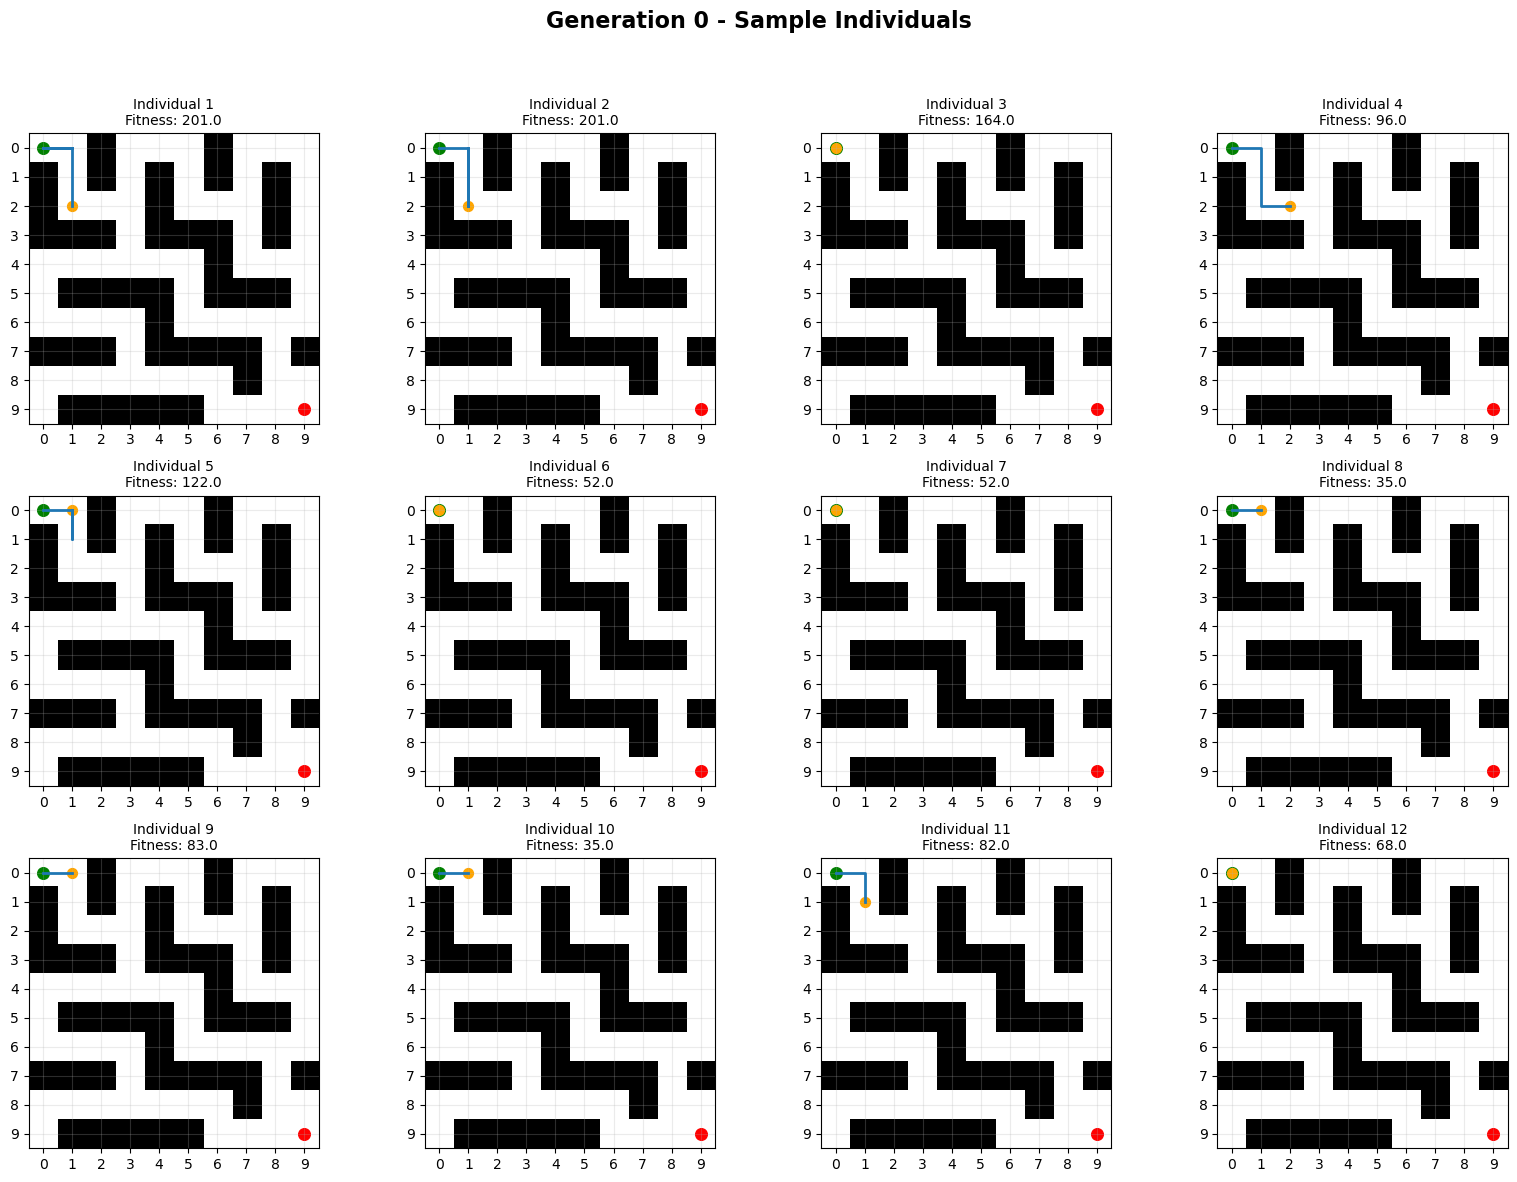

Gen 0050 | avg=   58.12 | best=   34.00 | depth= 1
Gen 0100 | avg=   43.12 | best=   34.00 | depth= 1
Gen 0150 | avg=   35.40 | best=   34.00 | depth= 1
Gen 0200 | avg=   34.77 | best=   33.00 | depth= 2
Gen 0250 | avg=   34.54 | best=   33.00 | depth= 2
Gen 0300 | avg=   34.27 | best=   33.00 | depth= 2
Gen 0350 | avg=   33.98 | best=   33.00 | depth= 2
Gen 0400 | avg=   33.74 | best=   33.00 | depth= 2
Gen 0450 | avg=   33.59 | best=   33.00 | depth= 2
Gen 0500 | avg=   33.44 | best=   33.00 | depth= 2
Gen 0550 | avg=   33.30 | best=   33.00 | depth= 2
Gen 0600 | avg=   33.17 | best=   33.00 | depth= 2
Gen 0650 | avg=   33.05 | best=   33.00 | depth= 2
Gen 0700 | avg=   33.00 | best=   33.00 | depth= 2
Gen 0750 | avg=   33.00 | best=   33.00 | depth= 2
Gen 0800 | avg=   33.00 | best=   33.00 | depth= 2
Gen 0850 | avg=   33.00 | best=   33.00 | depth= 2
Gen 0900 | avg=   33.00 | best=   33.00 | depth= 2
Gen 0950 | avg=   33.00 | best=   33.00 | depth= 2
Gen 1000 | avg=   33.00 | best=

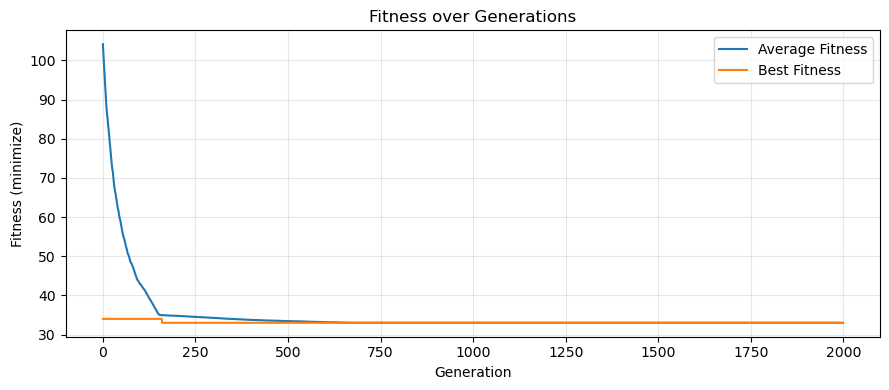

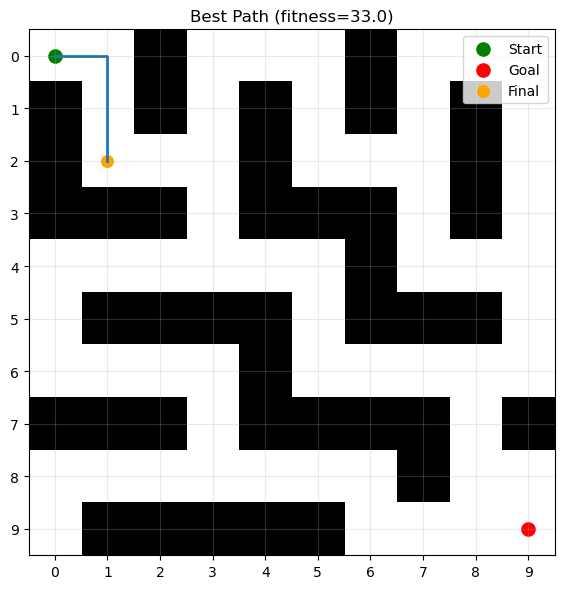

In [31]:
if __name__ == "__main__":
    main()
